# After meeting processing pipeline - 22/05/26
**Product:** BIO_S1_SCS__1S_20251202T041824_20251202T041837_T_G01_M01_C04_T032_F282_01_DKQZG1  
**Location:** Eastern Cape coast, South Africa (27.2°E–28.1°E, 33.6°S–32.7°S)  
**Collection:** BiomassLevel1a | **Type:** S1_SCS__1S

## 1.Imports


In [1]:
# conda install -c conda-forge polsarpro

In [2]:
import rasterio
import numpy as np
import os
from lxml import etree
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline
import xarray as xr
from scipy.ndimage import uniform_filter
from polsarpro.io import open_netcdf_beam
from polsarpro.util import (
    S_to_C3, S_to_T3, multilook, pauli_rgb, boxcar)
from polsarpro.decompositions import h_a_alpha
from polsarpro.speckle_filters import refined_lee

print('All imports done')

All imports done


## 2.File Paths

In [3]:
import os
# TO BE EDITED EACH TIME; Insert the product path after to region of interest folder
nom = r"C:\Users\Orlaith.Doyle\BIOMASS Essentials\biomass_product\BIO_S1_SCS__1S_20260210T033510_20260210T033531_T_G01_M02_C01_T003_F028_01_DMM676"
nom2 = os.path.basename(nom).lower().split("_01")[0]
TIFF_PATH_AMP = os.path.join(nom, "measurement", nom2 + "_i_abs.tiff") # Builds three files for the amplitude, Phase, and Annotation.
TIFF_PATH_PHA = os.path.join(nom, "measurement", nom2 + "_i_phase.tiff")
ANNOT_XML     = os.path.join(nom, "annotation",  nom2 + "_annot.xml")
repert = "output"
os.makedirs(repert, exist_ok=True)
print("Base name      :", nom2)
print("Amplitude TIFF :", TIFF_PATH_AMP)
print("Phase TIFF     :", TIFF_PATH_PHA)
print("Annotation XML :", ANNOT_XML)
for p in [TIFF_PATH_AMP, TIFF_PATH_PHA, ANNOT_XML]:
    if not os.path.exists(p):
        print(f"  WARNING: not found -> {p}")
    else:
        print(f"  OK: {p}")

Base name      : bio_s1_scs__1s_20260210t033510_20260210t033531_t_g01_m02_c01_t003_f028
Amplitude TIFF : C:\Users\Orlaith.Doyle\BIOMASS Essentials\biomass_product\BIO_S1_SCS__1S_20260210T033510_20260210T033531_T_G01_M02_C01_T003_F028_01_DMM676\measurement\bio_s1_scs__1s_20260210t033510_20260210t033531_t_g01_m02_c01_t003_f028_i_abs.tiff
Phase TIFF     : C:\Users\Orlaith.Doyle\BIOMASS Essentials\biomass_product\BIO_S1_SCS__1S_20260210T033510_20260210T033531_T_G01_M02_C01_T003_F028_01_DMM676\measurement\bio_s1_scs__1s_20260210t033510_20260210t033531_t_g01_m02_c01_t003_f028_i_phase.tiff
Annotation XML : C:\Users\Orlaith.Doyle\BIOMASS Essentials\biomass_product\BIO_S1_SCS__1S_20260210T033510_20260210T033531_T_G01_M02_C01_T003_F028_01_DMM676\annotation\bio_s1_scs__1s_20260210t033510_20260210t033531_t_g01_m02_c01_t003_f028_annot.xml
  OK: C:\Users\Orlaith.Doyle\BIOMASS Essentials\biomass_product\BIO_S1_SCS__1S_20260210T033510_20260210T033531_T_G01_M02_C01_T003_F028_01_DMM676\measurement\bio_s

In [4]:
with open(ANNOT_XML, 'rb') as f: # After Kernal restarts and run this cell reopens XML and rebuild xget
    tree = etree.parse(f)
def xget(xpath):
    nodes = tree.xpath(xpath)
    return nodes[0].text.strip() if nodes else "not found"
footprint_raw = xget('//footprint')
print("footprint_raw:", footprint_raw)

footprint_raw: 31.877950993536835 28.367921202851285 31.738110166530948 27.728726513937385 30.509869748966878 28.0897956462292 30.648316063355463 28.72138145779884


Nearest: Matruh


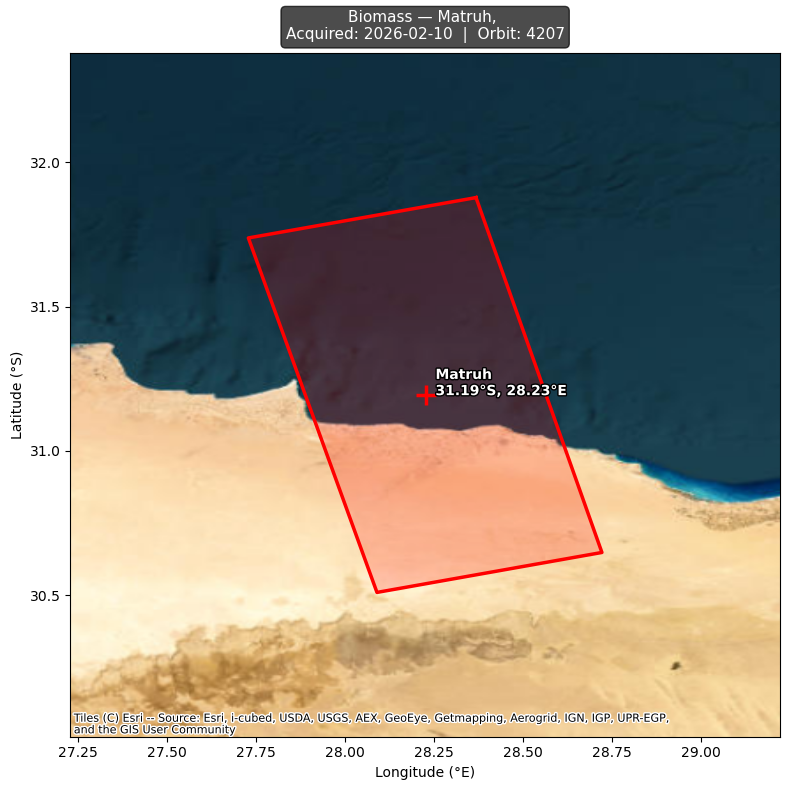

Saved: output/swath_location.png


In [5]:
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# EDIT: install if needed
# import sys
# !{sys.executable} -m pip install contextily geopy

from geopy.geocoders import Nominatim

fp      = [float(x) for x in footprint_raw.split()] # Corners
corners = [(fp[i], fp[i+1]) for i in range(0, len(fp), 2)]
lats    = [c[0] for c in corners]
lons    = [c[1] for c in corners]
lat_c   = sum(lats) / 4
lon_c   = sum(lons) / 4

geolocator = Nominatim(user_agent="biomass_pipeline") # Nearest place print for reffernce
location   = geolocator.reverse(f"{lat_c}, {lon_c}", language="en")
place      = location.address.split(',')[0] if location else "Area of Interest"
print("Nearest:", place)

fig, ax = plt.subplots(figsize=(8, 8))

pad = 0.5
ax.set_xlim(min(lons) - pad, max(lons) + pad)
ax.set_ylim(min(lats) - pad, max(lats) + pad)

ctx.add_basemap(ax, crs="EPSG:4326", # Add satellite basemap
                source=ctx.providers.Esri.WorldImagery,
                zoom=8)

xs = lons + [lons[0]] # Red swath
ys = lats + [lats[0]]
ax.plot(xs, ys, 'r-', linewidth=2.5)
ax.fill(lons, lats, color='red', alpha=0.2)

ax.plot(lon_c, lat_c, 'r+', markersize=14, markeredgewidth=2.5) # Centre marker
ax.annotate(f"  {place}\n  {lat_c:.2f}°S, {lon_c:.2f}°E",
            xy=(lon_c, lat_c), fontsize=10,
            color='white', fontweight='bold',
            path_effects=[plt.matplotlib.patheffects.withStroke(
                linewidth=2, foreground='black')])

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°S)")
ax.set_title(f"Biomass — {place}, \n"
             f"Acquired: {xget('//startTime')[:10]}  |  Orbit: {xget('//absoluteOrbitNumber')}",
             fontsize=11, color='white', pad=10,
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.savefig("output/swath_location.png", dpi=150, bbox_inches='tight') # TO BE EDITED FOR APPROPRIATE FILE SAVE LOCATION & NAME
plt.show()
print("Saved: output/swath_location.png") # ALSO EDITTED EACH PROJECT

In [6]:
#Slant to ground range projection, matching pixel to ground, incidence angle + 

## Cell 3. Parse polarisation list from annotation XML
Reads the XML to get the list of polarisations declared in the product.  
For a full-pol Biomass S1 product this should be `['hh', 'hv', 'vh', 'vv']`.

In [7]:
with open(ANNOT_XML, 'rb') as f: # To parse polarisation list (from Bjorn's Script)
    tree = etree.parse(f)
    pol_nodes     = tree.xpath('//polarisationList/polarisation')
    polarisations = [p.text.strip().lower() for p in pol_nodes]
print("Polarisation types found:", polarisations)
print("Number of bands expected:", len(polarisations))

Polarisation types found: ['hh', 'hv', 'vh', 'vv']
Number of bands expected: 4


## Cell 4. Read amplitude and phase TIFFs
Opens both TIFFs with rasterio. Each has one band per polarisation. Shape of each array will be `(n_pols, n_lines, n_samples)`.

In [9]:
with rasterio.open(TIFF_PATH_AMP) as srcamp: # Reads amplitude TIFF (from Bjorns script)
    print(f"Amplitude image : {srcamp.width} x {srcamp.height} px, {srcamp.count} bands")
    nsamples    = srcamp.width
    nlines      = srcamp.height
    matricesamp = srcamp.read()
    if len(polarisations) != srcamp.count:
        raise ValueError("Band count mismatch between XML polarisation list and amplitude TIFF")

with rasterio.open(TIFF_PATH_PHA) as srcpha: # Reads phase TIFF (from Bjorns script)
    print(f"Phase image     : {srcpha.width} x {srcpha.height} px, {srcpha.count} bands")
    matricespha = srcpha.read()
    if len(polarisations) != srcpha.count:
        raise ValueError("Band count mismatch between XML polarisation list and phase TIFF")

print(f"\nArray shape (n_pols, nlines, nsamples): {matricesamp.shape}")
print(f"Dtype amplitude: {matricesamp.dtype}")
print(f"Dtype phase    : {matricespha.dtype}")

Amplitude image : 1368 x 20747 px, 4 bands
Phase image     : 1368 x 20747 px, 4 bands

Array shape (n_pols, nlines, nsamples): (4, 20747, 1368)
Dtype amplitude: float32
Dtype phase    : float32


In [10]:
with open(ANNOT_XML, 'rb') as f: # Print list for all available product parameters taken directly from annotation XML
    tree = etree.parse(f)

def xget(xpath):
    nodes = tree.xpath(xpath)
    return nodes[0].text.strip() if nodes else "not found"

print("BIOMASS PRODUCT PARAMETERS")
print("________________________________________________________________________________________________________")
print("________________________________________________________________________________________________________")
print("PRODUCT ID")
print(f"  Product name      : {os.path.basename(nom)}")
print(f"  Base name         : {nom2}")
print(f"  Missio            : {xget('//mission')}")
print(f"  Swath             : {xget('//swath')}")
print(f"  Product type      : {xget('//productType')}")
print(f"  Processor ver     : {xget('//processorVersion')}")
print(f"  Generated         : {xget('//productGenerationTime')}")
print("________________________________________________________________________________________________________")
print("GEOGRAPHIC FOOTPRINT")
footprint = xget('//footprint')
print(f"  Footprint         : {footprint[:80]}...")
print("________________________________________________________________________________________________________")
print("ACQUISITION")
print(f"  Start time        : {xget('//startTime')}")
print(f"  Stop time         : {xget('//stopTime')}")
print(f"  Orbit pass        : {xget('//orbitPass')}")
print(f"  Absolute orbit    : {xget('//absoluteOrbitNumber')}")
print(f"  Relative orbit    : {xget('//relativeOrbitNumber')}")
print(f"  Major cycle ID    : {xget('//majorCycleID')}")
print(f"  Repeat cycle ID   : {xget('//repeatCycleID')}")
print(f"  Mission phase     : {xget('//missionPhaseID')}")
print(f"  Sensor mode       : {xget('//sensorMode')}")
print(f"  Data take ID      : {xget('//dataTakeID')}")
print(f"  Frame             : {xget('//frame')}")
print(f"  Platform heading  : {xget('//platformHeading')} °")
print("________________________________________________________________________________________________________")
print("RADAR PARAMETERS")
print(f"  Centre frequency  : {xget('//radarCarrierFrequency')} Hz")
print(f"  Polarisations     : {polarisations}")
print(f"  PRF               : {xget('//prfList/prf/value')} Hz")
print(f"  Pulse duration    : {xget('//txPulseList/txPulse/txPulseLength')} s")
print(f"  Pulse ramp rate   : {xget('//txPulseRampRate')} Hz/s")
print(f"  Rx gain           : {xget('//rxGainList/rxGain')} dB")
print(f"  RFI detection     : {xget('//rfiDetectionFlag')}")
print(f"  RFI correction    : {xget('//rfiCorrectionFlag')}")
print(f"  RFI FM fraction   : {xget('//rfiFMFraction')} (threshold 0.5)")
print(f"  Faraday rotation  : {xget('//faradayRotationCorrectionFlag')}")
print(f"  Ionosphere corr   : {xget('//ionosphericPhaseScreenCorrectionFlag')}")
print(f"  Pixel quantity    : {xget('//pixelQuantity')}")
print("________________________________________________________________________________________________________")
print("IMAGE GEOMETRY")
print(f"  Range spacing     : {xget('//rangePixelSpacing')} m")
print(f"  Azimuth spacing   : {xget('//azimuthPixelSpacing')} m")
print(f"  Number of samples : {xget('//numberOfSamples')} px")
print(f"  Number of lines   : {xget('//numberOfLines')} px")
print(f"  Projection        : {xget('//projection')}")
print(f"  First slant range : {xget('//firstSampleSlantRangeTime')} s")
print(f"  Last slant range  : {xget('//lastSampleSlantRangeTime')} s")
print(f"  First line time   : {xget('//firstLineAzimuthTime')}")
print(f"  Last line time    : {xget('//lastLineAzimuthTime')}")
print(f"  Incidence angle   : see LUT layer in annotation")
print(f"  Height model      : {xget('//heightModel')}")
print("________________________________________________________________________________________________________")
print("PROCESSING")
print(f"  Processing mode   : {xget('//processingMode')}")
print(f"  Range compression : {xget('//rangeCompressionMethod')}")
print(f"  Range bandwidth   : {xget('//rangeProcessingParameters/totalBandwidth')} Hz")
print(f"  Azimuth bandwidth : {xget('//azimuthProcessingParameters/totalBandwidth')} Hz")
print(f"  Range looks       : {xget('//rangeProcessingParameters/numberOfLooks')}")
print(f"  Azimuth looks     : {xget('//azimuthProcessingParameters/numberOfLooks')}")
print(f"  Cal constant      : {xget('//absoluteCalibrationConstant')} (linear)")
print(f"  Geocoded          : {xget('//groundProjectionFlag')}")
print("________________________________________________________________________________________________________")
print("QUALITY")
print(f"  Missing ISP frac  : {xget('//missingISPFraction')}")
print(f"  RFI FM fraction   : {xget('//rfiFMFraction')}")
print(f"  Iono phase std    : {xget('//residualIonosphericPhaseScreenStd')} rad")
print(f"  Invalid blocks    : {xget('//invalidBlocksPercentage')} %")
print("________________________________________________________________________________________________________")
print("IMAGE DIMENSIONS (from TIFF)")
print(f"  Azimuth lines     : {nlines} px")
print(f"  Range samples     : {nsamples} px")
print(f"  Total pixels      : {nlines * nsamples:,}")
print(f"  Amplitude dtype   : {matricesamp.dtype}")
print(f"  Phase dtype       : {matricespha.dtype}")

BIOMASS PRODUCT PARAMETERS
________________________________________________________________________________________________________
________________________________________________________________________________________________________
PRODUCT ID
  Product name      : BIO_S1_SCS__1S_20260210T033510_20260210T033531_T_G01_M02_C01_T003_F028_01_DMM676
  Base name         : bio_s1_scs__1s_20260210t033510_20260210t033531_t_g01_m02_c01_t003_f028
  Missio            : BIOMASS
  Swath             : S1
  Product type      : SCS
  Processor ver     : 4.3.1
  Generated         : 2026-02-10T13:43:04.862910
________________________________________________________________________________________________________
GEOGRAPHIC FOOTPRINT
  Footprint         : 31.877950993536835 28.367921202851285 31.738110166530948 27.728726513937385 30.5...
________________________________________________________________________________________________________
ACQUISITION
  Start time        : 2026-02-10T03:35:10.765391


## Cell 5. Write PolSARpro config.txt
Writes the config file that tells PolSARpro the image dimensions,  
polar case (monostatic) and polar type (full).

In [11]:
# To write PolSARpro configuration text file (Bjorn's script))
fichier = open(repert + "/config.txt", "w")
fichier.write("Nrow"      + "\n")
fichier.write(str(nlines) + "\n")
fichier.write("---------" + "\n")
fichier.write("Ncol"        + "\n")
fichier.write(str(nsamples) + "\n")
fichier.write("---------"   + "\n")
fichier.write("PolarCase"   + "\n")
fichier.write("monostatic"  + "\n")
fichier.write("---------"   + "\n")
fichier.write("PolarType"   + "\n")
fichier.write("full"        + "\n")
fichier.close()

print("config.txt written to:", repert + "/config.txt")

config.txt written to: output/config.txt


## Cell 6. Reconstruct complex SLC + write ENVI .bin + save PNG previews
For each polarisation:
- Reconstructs the complex SLC: `s = A·cos(φ) + j·A·sin(φ)`  
- Writes ENVI `.bin` + `.hdr` for PolSARpro (s11=HH, s12=HV, s21=VH, s22=VV)  
- Saves a dB-normalised PNG preview (6σ stretch)

In [12]:
# Per-polarisation loop (Bjorns Script)
pol_names = ["s11", "s12", "s21", "s22"]
imagecplx = np.zeros((nlines, nsamples), dtype=np.complex64)

for i in range(len(polarisations)):
    nomfich = pol_names[i]
    matamp  = matricesamp[i]
    matpha  = matricespha[i]
    # Write ENVI .hdr
    fichier = open(repert + "/" + nomfich + ".bin.hdr", "w")
    fichier.write("ENVI"                              + "\n")
    fichier.write("description = {"                   + "\n")
    fichier.write("PolSARpro File Imported to ENVI}" + "\n")
    fichier.write("samples = "     + str(nsamples)    + "\n")
    fichier.write("lines = "       + str(nlines)      + "\n")
    fichier.write("bands = 1"                         + "\n")
    fichier.write("header offset = 0"                 + "\n")
    fichier.write("file type = ENVI Standard"         + "\n")
    fichier.write("data type = 6"                     + "\n")
    fichier.write("interleave = bsq"                  + "\n")
    fichier.write("sensor type = Unknown"             + "\n")
    fichier.write("byte order = 0"                    + "\n")
    fichier.write("band names = {"                    + "\n")
    fichier.write(nomfich + ".bin }"                  + "\n")
    fichier.close()

    imagecplx = matamp * np.cos(matpha) + matamp * np.sin(matpha) * 1.0j # To reconstruct the complex SLC
    fichier = open(repert + "/" + nomfich + ".bin", "wb")     # To write ENVI .bin (complex64, little-endian)
    imagecplx.tofile(fichier)
    fichier.close()
    matamp_log  = 20.0 * np.log10(np.clip(matamp, 1e-4, 5.0))  # dB normalisation and PNG preview
    mu          = np.mean(matamp_log)
    sigma       = np.std(matamp_log)
    nbs         = 6.0
    vmin        = mu - nbs * sigma
    vmax        = mu + nbs * sigma
    matamp_norm = np.clip((matamp_log - vmin) / (vmax - vmin), 0.0, 1.0)
    matamp_u8   = (matamp_norm * 255.0).astype(np.uint8)
    img = Image.fromarray(matamp_u8, mode='L')
    img.save(repert + "/" + nomfich + ".png")
    print(f"{polarisations[i].upper()} ({nomfich})")
    print("________________________________________________________________________________________________________")
    print(f"  Amplitude  lin: min={np.min(matamp):.4f}  max={np.max(matamp):.4f}  mean={np.mean(matamp):.4f}")
    print(f"  Amplitude   dB: min={np.min(matamp_log):.2f}  max={np.max(matamp_log):.2f}  mean={mu:.2f}  std={sigma:.2f}")
    print(f"  Phase         : min={np.min(matpha):.4f}  max={np.max(matpha):.4f}  mean={np.mean(matpha):.4f}")
    print(f"  Written: {repert}/{nomfich}.bin  |  {repert}/{nomfich}.png")
    print("________________________________________________________________________________________________________")

HH (s11)
________________________________________________________________________________________________________
  Amplitude  lin: min=0.0001  max=11.4605  mean=0.2317
  Amplitude   dB: min=-80.00  max=13.98  mean=-15.28  std=7.27
  Phase         : min=-3.1416  max=3.1416  mean=0.0003
  Written: output/s11.bin  |  output/s11.png
________________________________________________________________________________________________________
HV (s12)
________________________________________________________________________________________________________
  Amplitude  lin: min=0.0000  max=1.6655  mean=0.0337
  Amplitude   dB: min=-80.00  max=4.43  mean=-31.52  std=6.36
  Phase         : min=-3.1416  max=3.1416  mean=0.0000
  Written: output/s12.bin  |  output/s12.png
________________________________________________________________________________________________________
VH (s21)
________________________________________________________________________________________________________
  Amplitude  l

## Cell 7. Plot all 4 polarisations side by side
Quick visual check of all four channels before any further processing.

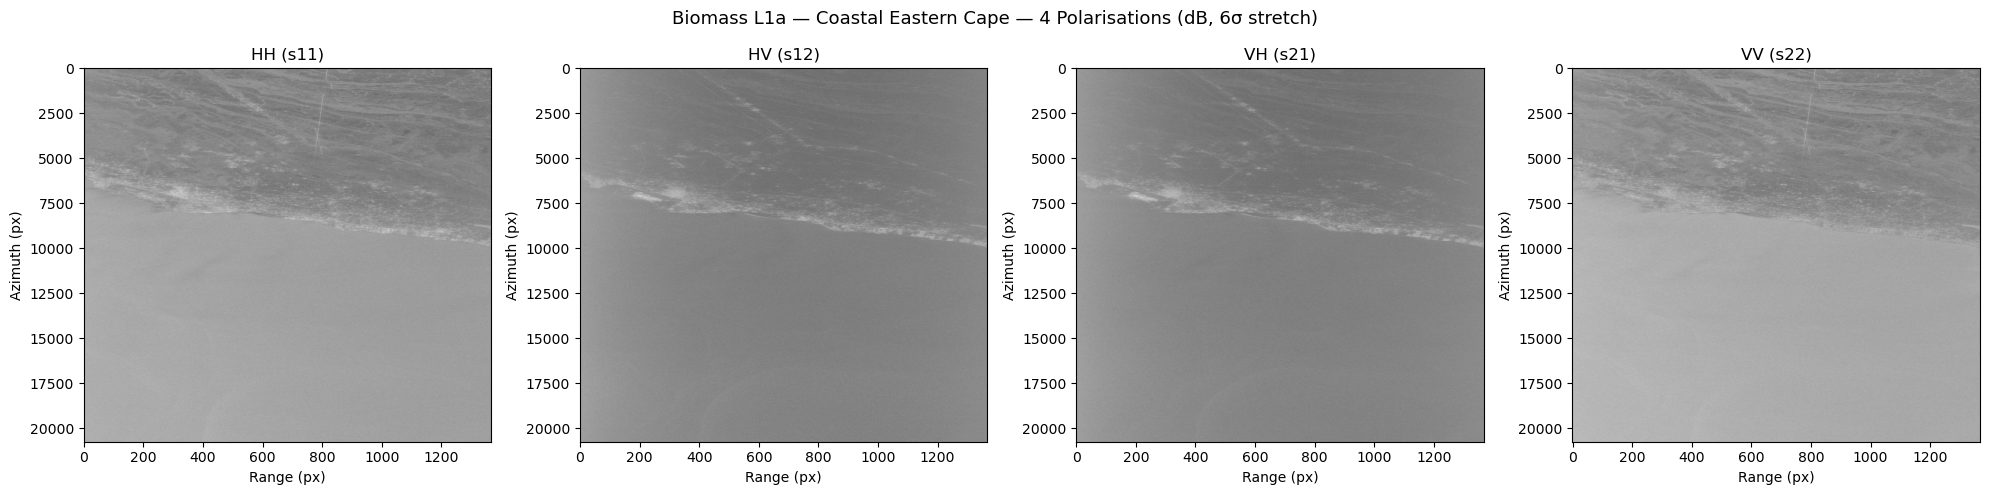

Saved: output/4pol_preview.png


In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5)) # To plot all 4 polarisations; HH, HV, VH, VV with Range (px) against Azimuth (px)
for i, (nomfich, pol) in enumerate(zip(pol_names, polarisations)):
    img_arr = np.array(Image.open(repert + "/" + nomfich + ".png"))
    axes[i].imshow(img_arr, cmap='gist_gray', aspect='auto')
    axes[i].set_title(f"{pol.upper()} ({nomfich})")
    axes[i].set_xlabel("Range (px)")
    axes[i].set_ylabel("Azimuth (px)")

plt.suptitle("Biomass L1a — Coastal Eastern Cape — 4 Polarisations (dB, 6σ stretch)",
             fontsize=13)
plt.tight_layout()
plt.savefig(repert + "/4pol_preview.png", dpi=150, bbox_inches='tight')  # TO BE EDITED FOR APPROPRIATE FILE NAME
plt.show()
print("Saved:", repert + "/4pol_preview.png") # TO BE EDITED FOR APPROPRIATE FILE NAME

## Cell 8. Build xarray S-matrix dataset for PolSARpro functions
The polsarpro functions (multilook, Pauli, H/A/Alpha) work on `xr.Dataset`.  
We build the S matrix dataset from the complex SLC arrays we already have.

In [22]:
#import sys
#!{sys.executable} -m pip install --upgrade dask

In [23]:
#import sys
#!{sys.executable} -m pip install "dask==2025.11.0" "distributed==2025.11.0"

In [24]:
# To rebuild all 4 complex SLC arrays from amplitude + phase
slc = {}
for i, pol in enumerate(polarisations):
    slc[pol] = (matricesamp[i] * np.cos(matricespha[i])
                + matricesamp[i] * np.sin(matricespha[i]) * 1.0j).astype(np.complex64)
y_coords = np.arange(nlines) # To build xarray S-matrix dataset (polsarpro convention), coords: y = azimuth pixel index, x = range pixel index
x_coords = np.arange(nsamples)
ds_S = xr.Dataset(
    {
        "hh": (["y", "x"], slc["hh"]),
        "hv": (["y", "x"], slc["hv"]),
        "vh": (["y", "x"], slc["vh"]),
        "vv": (["y", "x"], slc["vv"]),
    },
    coords={"y": y_coords, "x": x_coords},
    attrs={"poltype": "S", "description": "Scattering matrix — Biomass _ L1a"} # EDIT POINT; Biomass Coastal/Desert/Cryospheric/Other L1a
)
print(ds_S)
print("\nS matrix dataset ready. poltype:", ds_S.attrs["poltype"])

<xarray.Dataset> Size: 908MB
Dimensions:  (y: 20747, x: 1368)
Coordinates:
  * y        (y) int64 166kB 0 1 2 3 4 5 ... 20741 20742 20743 20744 20745 20746
  * x        (x) int64 11kB 0 1 2 3 4 5 6 ... 1361 1362 1363 1364 1365 1366 1367
Data variables:
    hh       (y, x) complex64 227MB (0.019978918-0.12742387j) ... (-0.1055691...
    hv       (y, x) complex64 227MB (-0.004782946+0.03459136j) ... (0.0445704...
    vh       (y, x) complex64 227MB (0.07833452+0.13200055j) ... (0.000953406...
    vv       (y, x) complex64 227MB (0.0017761148-0.030877378j) ... (-0.06852...
Attributes:
    poltype:      S
    description:  Scattering matrix — Biomass _ L1a

S matrix dataset ready. poltype: S


## Cell 9. Multilooking
Convert S → C3, then apply `multilook()` from polsarpro.util. Look numbers match the workshop notebook (18 azimuth, 3 range) EDIT: adjust look numbers if needed.  
Multilooking averages in intensity space, reducing speckle and squaring the pixels.

In [25]:
# Look numbers (solution notebooks: looksa=18, looksr=3 for Biomass). THIS CAN BE EDITED IF NECCESARY.
looksa = 18   # azimuth looks
looksr = 3    # range looks
ds_C3 = S_to_C3(ds_S) # Convert S → C3 (polsarpro.util)
print("C3 dataset:", ds_C3)

ds_C3_ml = multilook(ds_C3, dim_az=looksa, dim_rg=looksr) # Apply multilook (polsarpro.util)
print(f"\nAfter multilook ({looksa}az x {looksr}rg):")
print(f"  Input  shape: {nlines} x {nsamples}")
print(f"  Output shape: {ds_C3_ml.sizes['y']} x {ds_C3_ml.sizes['x']}")

C3 dataset: <xarray.Dataset> Size: 1GB
Dimensions:  (y: 20747, x: 1368)
Coordinates:
  * y        (y) int64 166kB 0 1 2 3 4 5 ... 20741 20742 20743 20744 20745 20746
  * x        (x) int64 11kB 0 1 2 3 4 5 6 ... 1361 1362 1363 1364 1365 1366 1367
Data variables:
    m11      (y, x) float32 114MB 0.01664 0.006853 0.01077 ... 0.004306 0.1094
    m22      (y, x) float32 114MB 0.01658 0.003169 ... 0.0004032 0.001868
    m33      (y, x) float32 114MB 0.0009566 0.03332 0.022 ... 0.01768 0.3471
    m12      (y, x) complex64 227MB (-0.013971232-0.008980647j) ... (0.005641...
    m13      (y, x) complex64 227MB (0.0039699995+0.0003905772j) ... (0.19069...
    m23      (y, x) complex64 227MB (-0.003544928+0.0018151191j) ... (0.01466...
Attributes:
    poltype:      C3
    description:  Covariance matrix (3x3)

After multilook (18az x 3rg):
  Input  shape: 20747 x 1368
  Output shape: 1152 x 456


## Cell 10. Spatial averaging with boxcar filter
Applies an additional boxcar (sliding window) spatial average on top of multilooking. This further reduces speckle before decomposition.

In [26]:
# Boxcar spatial averaging (polsarpro.util)
boxcar_az = 3
boxcar_rg = 3
ds_C3_ml_box = boxcar(ds_C3_ml, dim_az=boxcar_az, dim_rg=boxcar_rg)
print(f"Boxcar filter applied: {boxcar_az} x {boxcar_rg}")
print(f"Output shape unchanged: {ds_C3_ml_box.sizes['y']} x {ds_C3_ml_box.sizes['x']}")

Boxcar filter applied: 3 x 3
Output shape unchanged: 1152 x 456


## Cell 11. Pauli RGB decomposition
Computes the Pauli RGB from the multilooked C3 using `pauli_rgb()` from polsarpro.util:  
- **Red**   = |HH − VV|² → double-bounce or dihedral, Radar hits vertical surface so urban area & buildings.
- **Green** = |HV|²      → volume scattering, random radar bounce so maybe trees and biomass.
- **Blue**  = |HH + VV|² → surface scattering or odd-bounce, radar hits a flat surface like the ocean or a road.

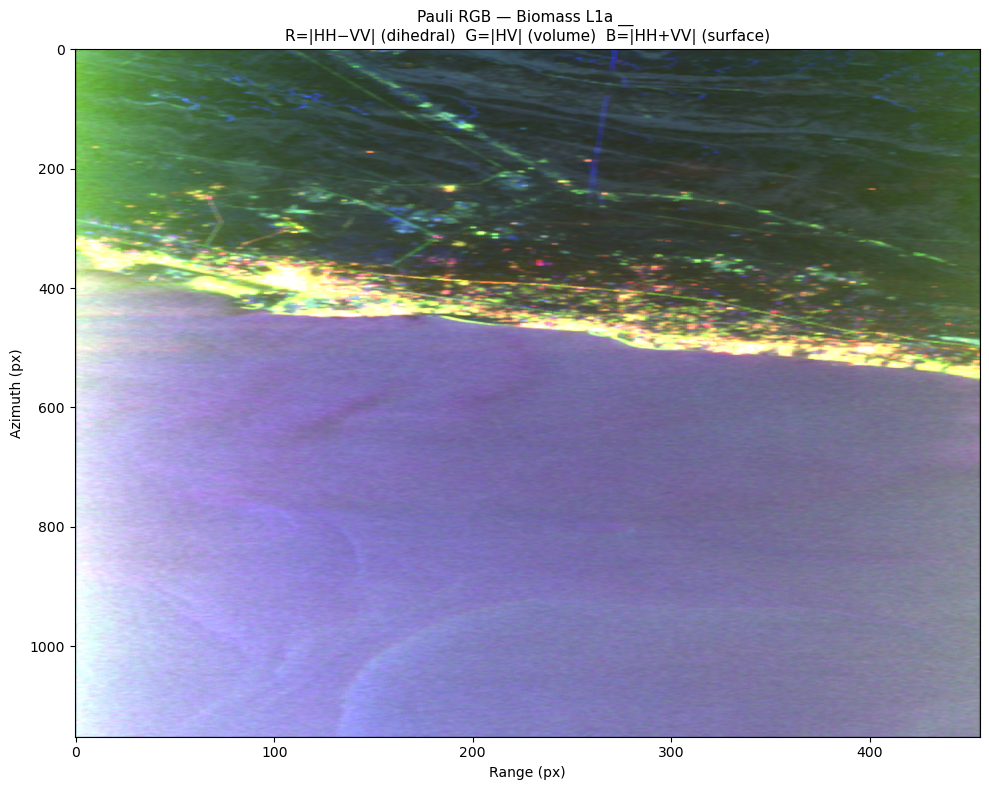

Saved: output/pauli_rgb.png


In [27]:
rgb = pauli_rgb(ds_C3_ml_box, q=0.98) # Pauli RGB from multilooked C3)
rgb_np = rgb.values  # rgb is an xr.DataArray with a 'band' dimension (0=R, 1=G, 2=B), shape: (3, nlines_ml, nsamples_ml)
rgb_display = np.transpose(rgb_np, (1, 2, 0)) # Transpose to (nlines, nsamples, 3) for imshow

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(rgb_display, aspect='auto')
ax.set_title("Pauli RGB — Biomass L1a __ \n"                                                                                           # EDIT HERE: For region of interest
             "R=|HH−VV| (dihedral)  G=|HV| (volume)  B=|HH+VV| (surface)",
             fontsize=11)
ax.set_xlabel("Range (px)")
ax.set_ylabel("Azimuth (px)")
plt.tight_layout()
plt.savefig(repert + "/pauli_rgb.png", dpi=150, bbox_inches='tight')                                                                   # EDIT HERE: For appropriate file name
plt.show()
print("Saved:", repert + "/pauli_rgb.png")

In [28]:
from PIL import Image
import numpy as np

# Load and check current orientation
img = Image.open("output/pauli_rgb.png")
print("Image size (width x height):", img.size)
print("Image mode:", img.mode)

# Check swath geometry
print("\nCorners (lat, lon):")
for i, (lat, lon) in enumerate(corners):
    print(f"  Corner {i+1}: {lat:.4f}, {lon:.4f}")

print(f"\nPlatform heading: {xget('//platformHeading')} °")
print(f"Orbit pass: {xget('//orbitPass')}")

Image size (width x height): (1483, 1181)
Image mode: RGBA

Corners (lat, lon):
  Corner 1: 31.8780, 28.3679
  Corner 2: 31.7381, 27.7287
  Corner 3: 30.5099, 28.0898
  Corner 4: 30.6483, 28.7214

Platform heading: -16.1266558057108 °
Orbit pass: Ascending


In [29]:
# Creates and saves a clean Pauli RGB image with no axes or border
rgb_np = rgb.values
rgb_display = np.transpose(rgb_np, (1, 2, 0))

fig, ax = plt.subplots(figsize=(rgb_display.shape[1]/100, rgb_display.shape[0]/100), dpi=100)
ax.imshow(rgb_display, aspect='auto')
ax.axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig("output/pauli_rgb_clean.png", dpi=100, bbox_inches='tight',                                                # EDIT HERE: For appropriate file save location and name
            pad_inches=0, transparent=True)
plt.close()
print("Saved: output/pauli_rgb_clean.png")                                                                             # EDIT HERE: For appropriate file save location and name

Saved: output/pauli_rgb_clean.png


## Cell 12. H/A/Alpha decomposition
Applies the Cloude-Pottier eigenvalue decomposition to the multilooked C3. Returns entropy H (0=pure, 1=random), anisotropy A, and mean alpha angle (°). For coastal areas: water → low H, low alpha; vegetation → high H, medium alpha.

In [31]:
# Convert multilooked C3 → T3 then run H/A/Alpha (polsarpro.decompositions), h_a_alpha accepts C3 directly — internal conversion handled automatically
ds_haa = h_a_alpha(
    ds_C3_ml_box,
    boxcar_size=[1, 1],      # already multilooked and boxcar'd — no extra smoothing
    flags=("entropy", "alpha", "anisotropy")
)
print("H/A/Alpha output variables:", list(ds_haa.data_vars))
print("Entropy    min:", float(ds_haa.entropy.min()),   "max:", float(ds_haa.entropy.max()))
print("Alpha      min:", float(ds_haa.alpha.min()),     "max:", float(ds_haa.alpha.max()), "(degrees)")
print("Anisotropy min:", float(ds_haa.anisotropy.min()),"max:", float(ds_haa.anisotropy.max()))

H/A/Alpha output variables: ['entropy', 'anisotropy', 'alpha']
Entropy    min: 0.027176709845662117 max: 0.9832853078842163
Alpha      min: 1.5329055786132812 max: 61.62963104248047 (degrees)
Anisotropy min: 0.005346946883946657 max: 0.9692820906639099


## Cell 13. Plot H, A, Alpha maps - Side-by-side maps of the three Cloude-Pottier parameters.

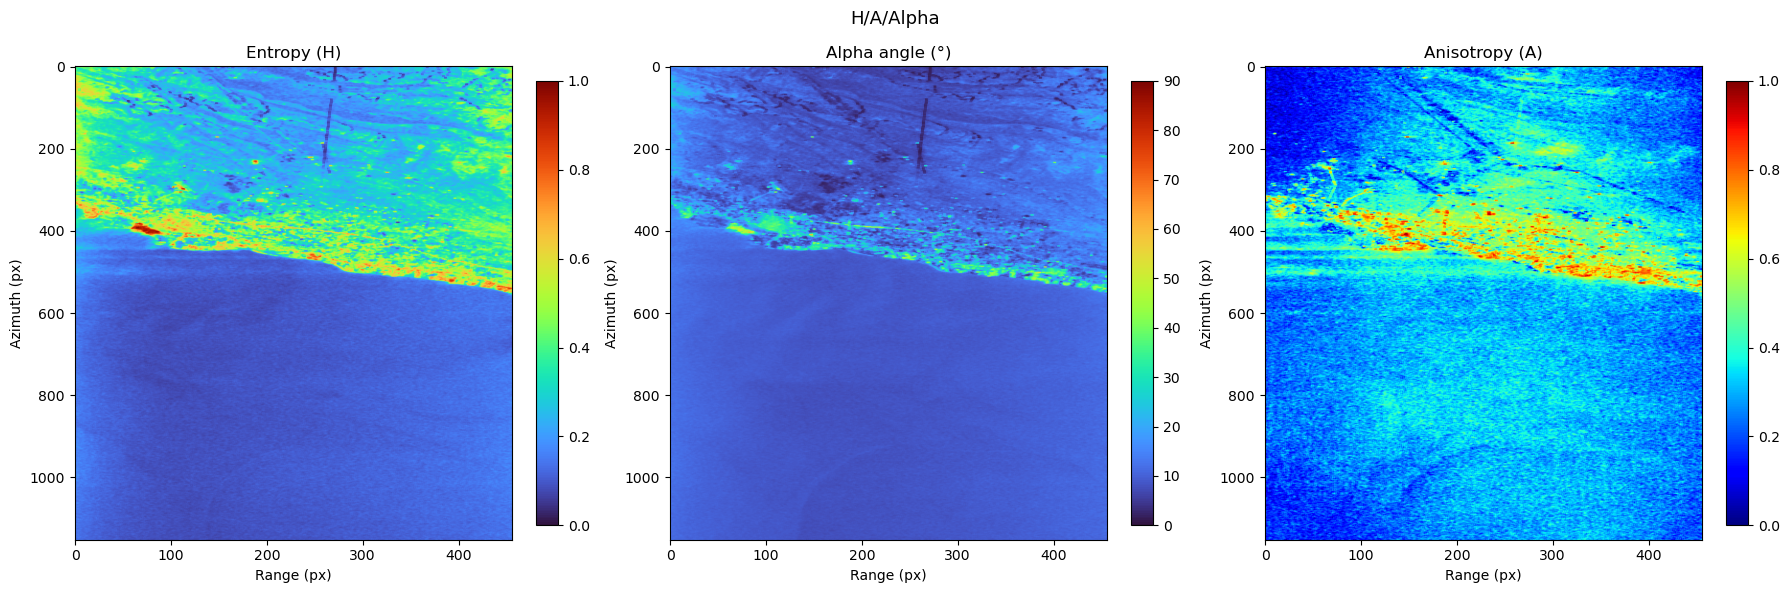

Saved: output/h_a_alpha.png


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Plot H / A / Alpha (solution notebooks style)
#####################################################
im0 = axes[0].imshow(ds_haa.entropy.values, cmap='turbo',
                     vmin=0, vmax=1, aspect='auto')
axes[0].set_title("Entropy (H)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)
#####################################################
im1 = axes[1].imshow(ds_haa.alpha.values, cmap='turbo',
                     vmin=0, vmax=90, aspect='auto')
axes[1].set_title("Alpha angle (°)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
#####################################################
im2 = axes[2].imshow(ds_haa.anisotropy.values, cmap='jet',
                     vmin=0, vmax=1, aspect='auto')
axes[2].set_title("Anisotropy (A)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
#####################################################
for ax in axes:
    ax.set_xlabel("Range (px)")
    ax.set_ylabel("Azimuth (px)")

plt.suptitle("H/A/Alpha", fontsize=13)
plt.tight_layout()
plt.savefig(repert + "/h_a_alpha.png", dpi=150, bbox_inches='tight')                                                   # EDIT HERE: For appropriate file save location and name
plt.show()
print("Saved:", repert + "/h_a_alpha.png")                                                                             # EDIT HERE: For appropriate file name

## Cell 14. 2D histogram of H vs Alpha plane plot
This is the standard PolSAR scatter plot used to classify scattering mechanisms. Coastal zones should cluster in the low-H, low-Alpha region (surface scattering from water).

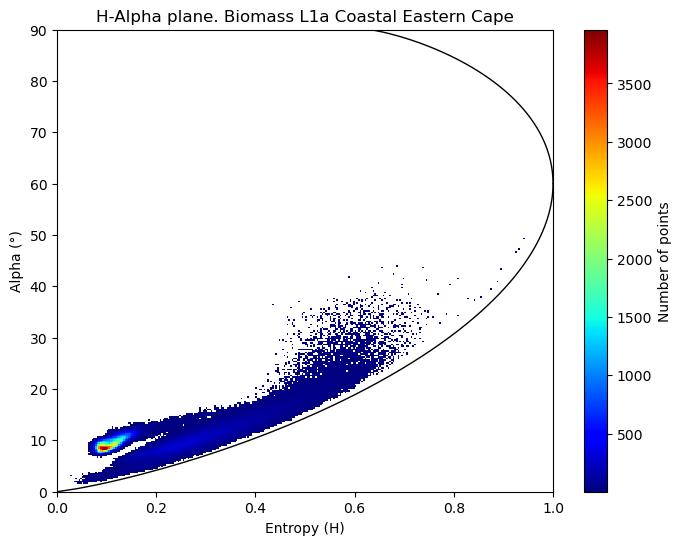

Saved: output/h_alpha_plane.png


In [33]:
from polsarpro.util import plot_h_alpha_plane
# H-Alpha plane (polsarpro.util)
ax, fig = plot_h_alpha_plane(ds_haa, bins=300, min_pts=3)
ax.set_title("H-Alpha plane. Biomass L1a Coastal Eastern Cape")                                                       # EDIT HERE: For appropriate file save location and name
fig.savefig(repert + "/h_alpha_plane.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", repert + "/h_alpha_plane.png")

## Cell 15. Summary of all outputs
Lists everything written to the output folder.

In [34]:
# Quick summary table
print("OUTPUT FILES")
print("________________________________________________________________________________________________________")
for f in sorted(os.listdir(repert)):
    size = os.path.getsize(os.path.join(repert, f))
    print(f"  {f:<35} {size/1024:>8.1f} KB")
print("________________________________________________________________________________________________________")

OUTPUT FILES
________________________________________________________________________________________________________
  .ipynb_checkpoints                       0.0 KB
  4pol_preview.png                      1081.3 KB
  T3_crop_box_5x5.nc                  250889.9 KB
  config.txt                               0.1 KB
  h_a_alpha.nc                          5872.7 KB
  h_a_alpha.png                         2269.9 KB
  h_a_alpha_plane.png                     57.3 KB
  h_alpha_plane.png                       71.2 KB
  pauli_rgb.png                         1718.9 KB
  pauli_rgb_clean.png                    877.9 KB
  s11.bin                             221733.6 KB
  s11.bin.hdr                              0.2 KB
  s11.png                              22541.0 KB
  s12.bin                             221733.6 KB
  s12.bin.hdr                              0.2 KB
  s12.png                              23182.2 KB
  s21.bin                             221733.6 KB
  s21.bin.hdr                   